# LSS Data Re-Analysis: Investigating LNT Threshold
This notebook analyzes the Life Span Study (LSS) dataset to predict solid cancer deaths using `colon10` as the dose metric (converted to mSv), weighted by person-years (`pyr`), and controlling for `agecat`, `agexcat`, `sex`, and `city`.

In [1]:
!pip install pandas numpy xgboost shap statsmodels matplotlib pygam

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 6.7 MB/s eta 0:00:16
   -- ------------------------------------- 5.2/101.7 MB 16.8 MB/s eta 0:00:06
   ----- ---------------------------------- 14.7/101.7 MB 28.8 MB/s eta 0:00:04
   --------- ------------------------------ 24.9/101.7 MB 35.1 MB/s eta 0:00:03
   ------------- -------------------------- 35.4/101.7 MB 38.8 MB/s eta 0:00:02
   ---------------- ----------------------- 42.5/101.7 MB 39.2 MB/s eta 0:00:02
   ------------------- -------------------- 48.8/101.7 MB 36.5 MB/s eta 0:00:02
   ------------------------ --------------- 61.9/101.7 MB 40.2 MB/s eta 0:00:01
   --------------------------- ------------ 70.3/101.7 MB 40.4 MB/s eta 0:00:01
   ------------------------------- -------- 80.2/101.7 MB 41.3 MB/s eta 0:00:01
   ----------------------------------- ---- 90.7/101.7 MB 42.3 MB/s e

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from pygam import PoissonGAM, s, f
import warnings
warnings.filterwarnings('ignore')

# 1. Data Preparation
df = pd.read_csv('lss14.csv')

# Handle missing/placeholder values (-99.00000)
df = df.replace(-99.00000, np.nan).dropna(subset=['solid', 'colon10', 'pyr', 'agecat', 'agexcat', 'sex', 'city'])

# Convert dose from mGy to mSv (multiplier of 1000)
df['colon10_msv'] = df['colon10'] * 1000

# Offset for Poisson regression
df['log_pyr'] = np.log(df['pyr'])

features = ['colon10_msv', 'agecat', 'agexcat', 'sex', 'city']
X = df[features]
y = df['solid']
offset = df['log_pyr']

print(f"Data loaded. Shape: {df.shape}")

c:\Project\Radiation Research\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded. Shape: (53782, 53)


<Figure size 1000x600 with 0 Axes>

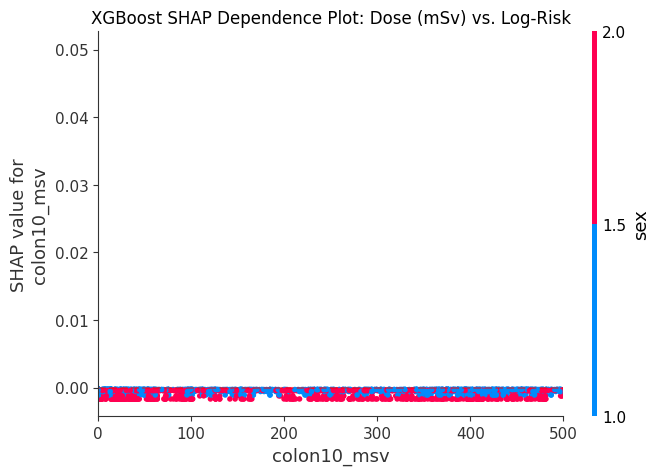

In [3]:
# 2. XGBoost with SHAP Analysis
dtrain = xgb.DMatrix(X, label=y, base_margin=offset)
params = {
    'objective': 'count:poisson',
    'tree_method': 'hist',
    'eval_metric': 'poisson-nloglik',
    'learning_rate': 0.05,
    'max_depth': 4
}
bst = xgb.train(params, dtrain, num_boost_round=150)

# Calculate SHAP values
explainer = shap.TreeExplainer(bst)
shap_values = explainer.shap_values(X)

# Plot SHAP Dependence for Dose
plt.figure(figsize=(10, 6))
shap.dependence_plot("colon10_msv", shap_values, X, show=False)
plt.title("XGBoost SHAP Dependence Plot: Dose (mSv) vs. Log-Risk")
plt.xlim(0, 500) # Zoom into low dose region (0-500 mSv)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [4]:
# 3. Segmented (Piecewise) Poisson Regression
# Scanning through possible threshold values to find the one that minimizes AIC
thresholds = np.linspace(5, 200, 40) # Test thresholds between 5 and 200 mSv
best_aic = np.inf
best_t = 0
best_model = None

for t in thresholds:
    # Create a piecewise term: 0 if dose < t, else (dose - t)
    df['dose_above_t'] = np.maximum(0, df['colon10_msv'] - t)
    
    formula = 'solid ~ colon10_msv + dose_above_t + C(agecat) + C(agexcat) + C(sex) + C(city)'
    try:
        model = smf.glm(formula=formula, data=df, family=sm.families.Poisson(), offset=df['log_pyr']).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_t = t
            best_model = model
    except:
        continue

print(f"Optimal Threshold found at: {best_t:.2f} mSv (Minimized AIC)")
if best_model:
    print(best_model.summary().tables[1])

Optimal Threshold found at: 5.00 mSv (Minimized AIC)
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -31.4874   2.92e+04     -0.001      0.999   -5.72e+04    5.71e+04
C(agecat)[T.3]      -0.0977   3.38e+04  -2.89e-06      1.000   -6.63e+04    6.63e+04
C(agecat)[T.4]      19.9080   2.92e+04      0.001      0.999   -5.71e+04    5.72e+04
C(agecat)[T.5]      21.0807   2.92e+04      0.001      0.999   -5.71e+04    5.72e+04
C(agecat)[T.6]      21.7695   2.92e+04      0.001      0.999   -5.71e+04    5.72e+04
C(agecat)[T.7]      23.1206   2.92e+04      0.001      0.999   -5.71e+04    5.72e+04
C(agecat)[T.8]      23.6354   2.92e+04      0.001      0.999   -5.71e+04    5.72e+04
C(agecat)[T.9]      24.2276   2.92e+04      0.001      0.999   -5.71e+04    5.72e+04
C(agecat)[T.10]     24.6395   2.92e+04      0.001      0.999   -5.71e+04    5.72e+04
C(agecat)[T.

In [5]:
# 4. Generalized Additive Model (GAM) as proxy for Neural GAM
# Fits spline shapes to visualize the threshold in a smooth dose-response curve.
# Features: colon10_msv (continuous: s), others are categorical (f)
gam = PoissonGAM(s(0, n_splines=15) + f(1) + f(2) + f(3) + f(4)).fit(X.values, y.values, exposure=df['pyr'].values)

plt.figure(figsize=(10, 6))
XX = gam.generate_X_grid(term=0)
pdep, confi = gam.partial_dependence(term=0, X=XX, width=0.95)

plt.plot(XX[:, 0], pdep)
plt.fill_between(XX[:, 0], confi[:, 0], confi[:, 1], alpha=0.3)
plt.title('GAM Partial Dependence: Dose (mSv)')
plt.xlabel('colon10_msv')
plt.ylabel('Multiplier on Expected Counts')
plt.xlim(0, 500) # Zoom into low dose
plt.axhline(1, color='red', linestyle='--', alpha=0.5)
plt.show()

ValueError: X data is out of domain for categorical feature 1. Expected data on [2.0, 21.0], but found data on [0.0, 0.0]

<Figure size 1000x600 with 0 Axes>